# Tutorial Denoising

> denoising


In [ ]:
#| default_exp tutorial_3

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_dataset_from_csv

from monai.utils import set_determinism

set_determinism(0)

In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
# Specify the directory where you want to save the downloaded files
output_directory = "../_data/FMD"
# Define the base URL for the dataset
base_url = 'https://s3.ap-northeast-1.wasabisys.com/gigadb-datasets/live/pub/10.5524/100001_101000/100888/'

# Download only the first two images
download_dataset_from_csv('./data_examples/FMD_dataset_info.csv', base_url, output_directory, rows=[0,1])

### Sorting & Preprocessing data

The all images are in the same file, so we are going to separate them.

In [ ]:
# extract images from stack and save them in X and y folders
X_path = '../_data/FMD/04-actin-20x-noise1/X'
y_path = '../_data/FMD/04-actin-20x-noise1/y'
# extract_substacks('../_data/FMD/04-actin-20x-noise1/actin-20x-noise1-lowsnr.tif', output_dir=X_path, indices={'Z': range(100)}, split_dimension="Z")
# extract_substacks('../_data/FMD/04-actin-20x-noise1/actin-20x-noise1-highsnr.tif', output_dir=y_path, indices={'Z': range(100)}, split_dimension="Z")

Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z0.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z1.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z2.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z3.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z4.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z5.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z6.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z7.ome.tiff
Extracted substack saved to: ../_data/FMD/04-actin-20x-noise1/X/actin-20x-noise1-lowsnr_substack_Z8.ome.tiff
Extracted substack 

### Create Dataloader

In [ ]:
bs = 16
patch_size = 128

itemTfms = [RandCropND(patch_size), RandRot90(prob=.5), RandFlip(prob=0.75)]
batchTfms = [ScaleIntensity(min=0.0, max=1.0)]

get_target_fn = get_target(y_path, same_filename=False, target_file_prefix="actin-20x-noise1-highsnr", signal_file_prefix="actin-20x-noise1-lowsnr")

data = BioDataLoaders.from_folder(
    X_path, 
    get_target_fn, 
    valid_pct=0.2, 
    seed=42, 
    item_tfms=itemTfms,
    batch_tfms=batchTfms, 
    show_summary=False,
    bs = bs,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 80 
validation images: 20


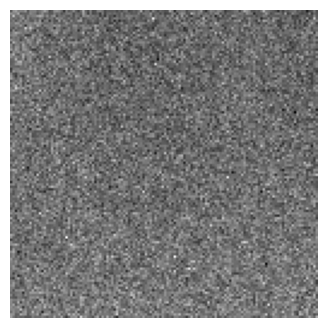

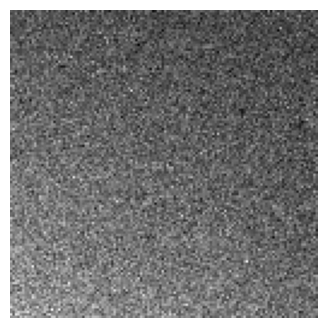

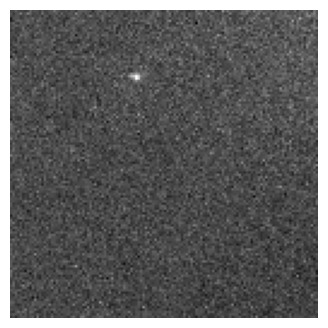

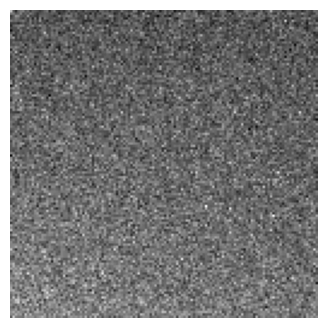

In [ ]:
data.show_batch(max_n=4)

### Load and train a 2D model

In [ ]:
# from bioMONAI.nets import Deeplab, DeeplabConfig
from monai.networks.nets import BasicUNet, AttentionUnet, DynUNet, UNet, BasicUNet


In [ ]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256),strides=(2, 2, 2, 2), num_res_units=2).model
# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
# model = BasicUNet(spatial_dims=3, in_channels=1, out_channels=1)
# config_2d = DeeplabConfig(
#     dimensions=3,
#     in_channels=1,  
#     out_channels=1,
#     backbone="resnet10",  
#     aspp_dilations=[1]
# )
# model = Deeplab(config_2d)

In [ ]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2)
model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) 

loss = CombinedLoss(alpha=0.00001, beta=0.00001)

metrics = [MSEMetric(), SSIMMetric(2), PSNRMetric(1)]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

epoch,train_loss,valid_loss,MSE,SSIM,PSNR,time
0,4.980501,6.336070,533092.687500,0.000025,-53.614552,00:03
1,5.809904,6.331801,532668.125000,0.000048,-53.608665,00:03
2,5.673342,6.329413,532430.875000,0.000062,-53.605206,00:03


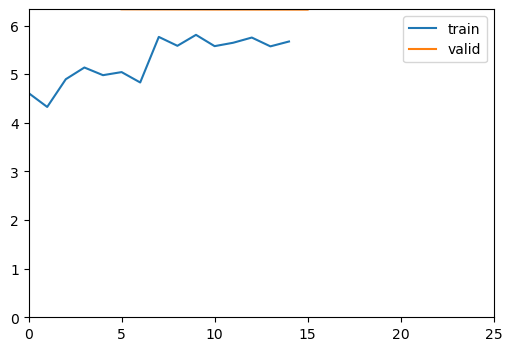

In [ ]:
trainer.fit_flat_cos(5)

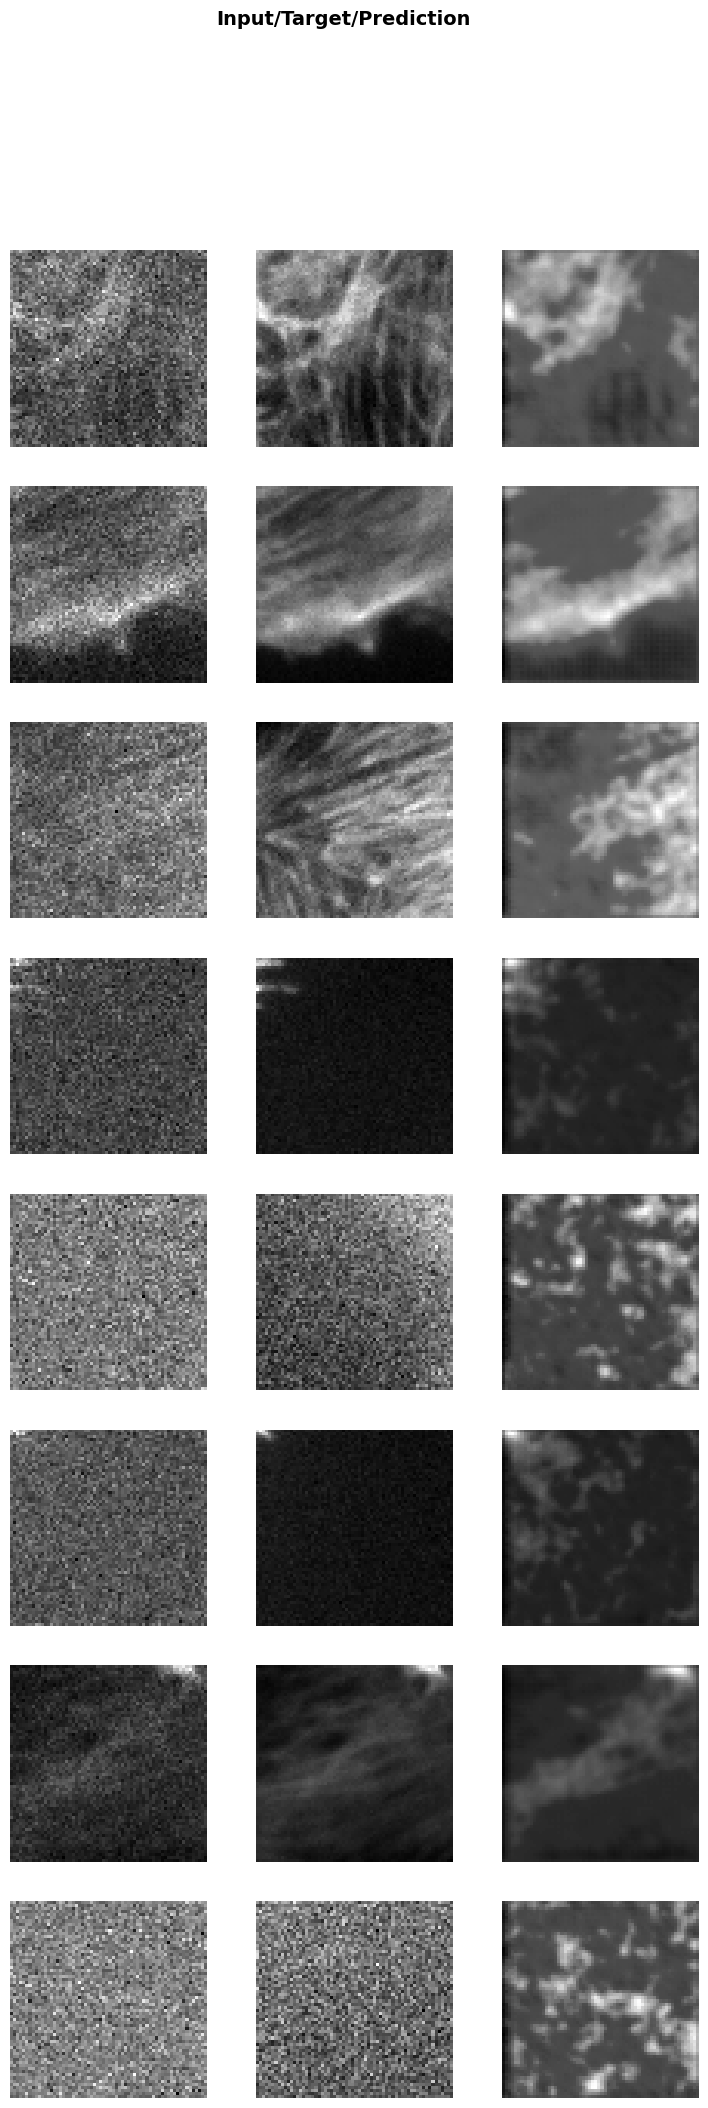

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!